# Modèle de régression - Prédiction de la température (Cotonou)

Ce notebook entraîne et compare 3 modèles pour prédire la température moyenne
à partir de 7 caractéristiques météorologiques.

**Modèles comparés :** régression linéaire (baseline), Random Forest, Gradient Boosting.

**Métriques :** MAE, RMSE, R².


## 1. Imports et configuration

In [1]:
import sys
import os

# Permet d'importer les modules du dossier src/ depuis ce notebook,
# qui se trouve dans notebooks/ (donc un niveau en dessous de la racine)
sys.path.append(os.path.dirname(os.getcwd()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from src.data_loading import charger_donnees
from src.features import preparer_features, creer_cible_temperature
from src.config import FEATURES_COMMUNES, TAILLE_TEST, NB_FOLDS_CV, RANDOM_STATE

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")


Matplotlib is building the font cache; this may take a moment.


## 2. Chargement et préparation des données

**Ordre important :** `charger_donnees()` doit être appelée avant
`preparer_features()`, car c'est elle qui crée la colonne `mois` à partir
de `time`. Inverser l'ordre provoquerait un `KeyError`.


In [2]:
CHEMIN_CSV = "../data/data_OPEN_METEO.csv"

df = charger_donnees(CHEMIN_CSV)
df = preparer_features(df)

print(f"Dimensions du dataset : {df.shape}")
df.head()


Dimensions du dataset : (3653, 22)


,time,weather_code (wmo code),temperature_2m_max (°C),temperature_2m_min (°C),temperature_2m_mean (°C),precipitation_sum (mm),rain_sum (mm),precipitation_hours (h),wind_speed_10m_max (km/h),wind_gusts_10m_max (km/h),wind_direction_10m_dominant (°),relative_humidity_2m_mean (%),surface_pressure_mean (hPa),cloud_cover_mean (%),sunshine_duration (s),mois,humidite,pression,vent_vitesse,vent_rafales,nuages,sunshine_duration_heures
0,2015-01-01,2,29.3,24.5,26.9,0.0,0.0,0.0,17.0,34.9,215,79,1010.2,10,41319.21,1,79,1010.2,17.0,34.9,10,11.477558
1,2015-01-02,0,29.2,24.6,27.0,0.0,0.0,0.0,15.1,32.0,204,78,1011.0,4,41278.21,1,78,1011.0,15.1,32.0,4,11.466169
2,2015-01-03,3,28.9,24.7,26.9,0.0,0.0,0.0,16.7,31.3,174,83,1012.2,39,40985.12,1,83,1012.2,16.7,31.3,39,11.384756
3,2015-01-04,3,29.4,23.9,26.5,0.0,0.0,0.0,12.7,24.5,117,73,1012.6,15,41837.27,1,73,1012.6,12.7,24.5,15,11.621464
4,2015-01-05,0,29.1,23.0,25.8,0.0,0.0,0.0,12.3,24.1,91,57,1012.2,0,41934.91,1,57,1012.2,12.3,24.1,0,11.648586


In [3]:
# Vérification des valeurs manquantes sur les colonnes utiles
colonnes_a_verifier = FEATURES_COMMUNES + ["temperature_2m_mean (°C)"]
df[colonnes_a_verifier].isna().sum()


humidite                    0
pression                    0
vent_vitesse                0
vent_rafales                0
nuages                      0
mois                        0
sunshine_duration_heures    0
temperature_2m_mean (°C)    0
dtype: int64

## 3. Analyse 

In [4]:
df[FEATURES_COMMUNES + ["temperature_2m_mean (°C)"]].describe()


,humidite,pression,vent_vitesse,vent_rafales,nuages,mois,sunshine_duration_heures,temperature_2m_mean (°C)
count,3653.000000,3653.000000,3653.000000,3653.000000,3653.000000,3653.000000,3653.000000,3653.000000
mean,82.963865,1010.526088,18.177498,34.407309,67.578976,6.522310,9.714151,27.062031
std,5.033492,1.739281,3.471260,5.291037,24.984247,3.449345,2.457421,1.311290
min,40.000000,1005.900000,7.300000,18.000000,0.000000,1.000000,0.000000,23.800000
25%,82.000000,1009.200000,15.700000,30.600000,51.000000,4.000000,9.372911,25.900000
50%,84.000000,1010.400000,17.900000,34.200000,72.000000,7.000000,10.509347,27.300000
75%,86.000000,1011.800000,20.400000,37.800000,89.000000,10.000000,11.112694,28.100000
max,93.000000,1016.100000,40.200000,66.600000,100.000000,12.000000,12.000000,30.600000


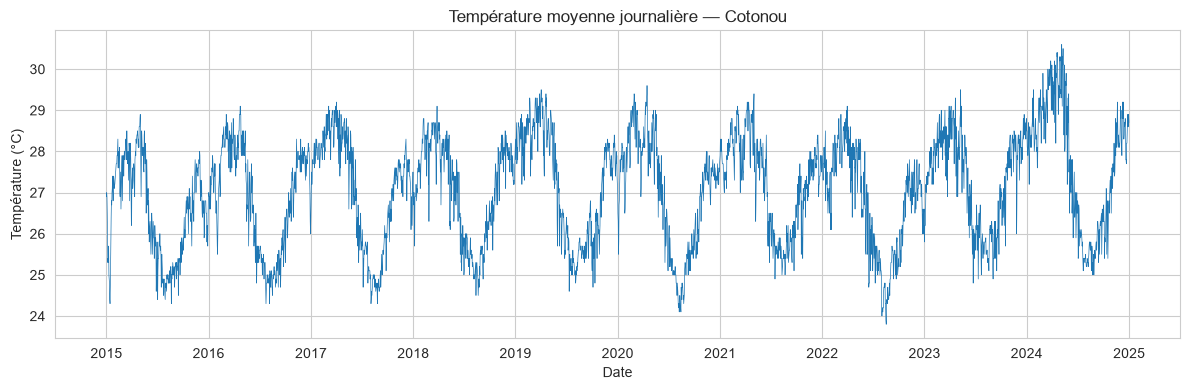

In [5]:
# Évolution de la température dans le temps (vérification de cohérence
# avec le climat de Cotonou : pas de grosses variations saisonnières)
plt.figure(figsize=(12, 4))
plt.plot(df["time"], df["temperature_2m_mean (°C)"], linewidth=0.5)
plt.title("Température moyenne journalière — Cotonou")
plt.xlabel("Date")
plt.ylabel("Température (°C)")
plt.tight_layout()
plt.show()


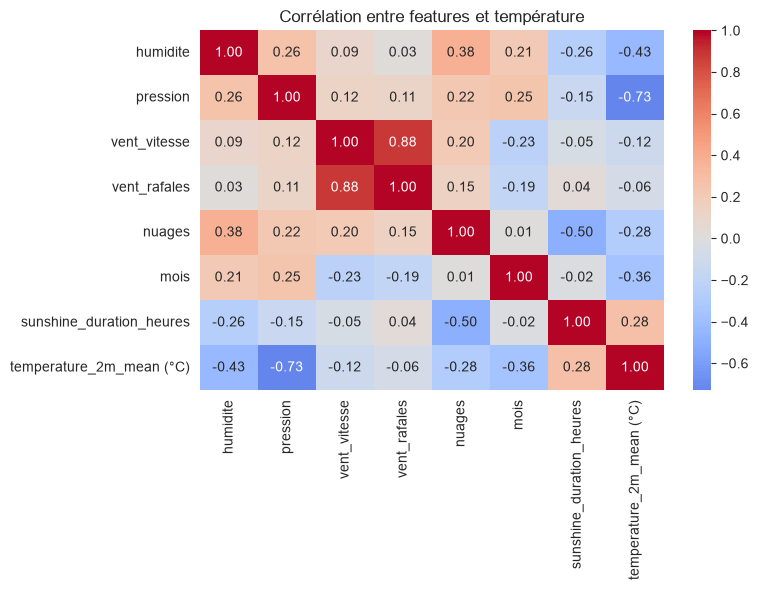

In [6]:
# Matrice de corrélation entre les features et la cible
colonnes_corr = FEATURES_COMMUNES + ["temperature_2m_mean (°C)"]
matrice_corr = df[colonnes_corr].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(matrice_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Corrélation entre features et température")
plt.tight_layout()
plt.show()


**À observer ici :** si une feature a une corrélation quasi nulle avec la
température, ce n'est pas forcément un problème les modèles à base d'arbres
(Random Forest, Gradient Boosting) peuvent capturer des relations non
linéaires qu'une simple corrélation ne montre pas. Ce graphique sert surtout
à détecter une éventuelle anomalie (par exemple une feature mal chargée).


## 4. Construction de X, y et split train/test

In [7]:
X = df[FEATURES_COMMUNES]
y = creer_cible_temperature(df)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TAILLE_TEST, random_state=RANDOM_STATE
)

print(f"Train : {X_train.shape[0]} lignes | Test : {X_test.shape[0]} lignes")


Train : 2922 lignes | Test : 731 lignes


## 5. Modèle 1 — Régression linéaire (baseline)

In [8]:
modele_lineaire = LinearRegression()

scores_cv = cross_val_score(
    modele_lineaire, X_train, y_train,
    cv=NB_FOLDS_CV, scoring="neg_mean_absolute_error"
)

print(f"MAE moyenne en validation croisée : {-scores_cv.mean():.2f} °C (+/- {scores_cv.std():.2f})")

# Entraînement final sur tout le train set, pour la comparaison finale (section 8)
modele_lineaire.fit(X_train, y_train)


MAE moyenne en validation croisée : 0.63 °C (+/- 0.01)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](7,)","[-0.05,-0.47,-0.07,..., 0. ,-0.07, 0.07]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](7,)","['humidite','pression','vent_vitesse',...,'nuages','mois', 'sunshine_duration_heures']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,504
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(7)


## 6. Modèle 2 — Random Forest (RandomizedSearchCV)

In [ ]:
grille_random_forest = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}

recherche_rf = RandomizedSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE),
    param_distributions=grille_random_forest,
    n_iter=25,
    cv=NB_FOLDS_CV,
    scoring="neg_mean_absolute_error",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

recherche_rf.fit(X_train, y_train)

print("Meilleurs hyperparamètres Random Forest :", recherche_rf.best_params_)
print(f"MAE moyenne en validation croisée : {-recherche_rf.best_score_:.2f} °C")

modele_random_forest = recherche_rf.best_estimator_


## 7. Modèle 3 — Gradient Boosting (RandomizedSearchCV)

In [ ]:
grille_gradient_boosting = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [2, 3, 4, 5],
    "subsample": [0.7, 0.85, 1.0],
}

recherche_gb = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=RANDOM_STATE),
    param_distributions=grille_gradient_boosting,
    n_iter=25,
    cv=NB_FOLDS_CV,
    scoring="neg_mean_absolute_error",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

recherche_gb.fit(X_train, y_train)

print("Meilleurs hyperparamètres Gradient Boosting :", recherche_gb.best_params_)
print(f"MAE moyenne en validation croisée : {-recherche_gb.best_score_:.2f} °C")

modele_gradient_boosting = recherche_gb.best_estimator_


## 8. Comparaison finale sur le test set



In [ ]:
def evaluer_modele(nom, modele, X_test, y_test):
    predictions = modele.predict(X_test)
    return {
        "Modèle": nom,
        "MAE (°C)": mean_absolute_error(y_test, predictions),
        "RMSE (°C)": np.sqrt(mean_squared_error(y_test, predictions)),
        "R²": r2_score(y_test, predictions),
    }

resultats = [
    evaluer_modele("Régression linéaire", modele_lineaire, X_test, y_test),
    evaluer_modele("Random Forest", modele_random_forest, X_test, y_test),
    evaluer_modele("Gradient Boosting", modele_gradient_boosting, X_test, y_test),
]

tableau_resultats = pd.DataFrame(resultats).sort_values("MAE (°C)")
tableau_resultats


## 9. Sélection et sauvegarde du modèle final



In [ ]:
MODELE_FINAL = modele_gradient_boosting

CHEMIN_SORTIE = "../models/model_temperature.pkl"
joblib.dump(MODELE_FINAL, CHEMIN_SORTIE)

print(f"Modèle sauvegardé dans {CHEMIN_SORTIE}")


## 10. Importance des features

In [ ]:
if hasattr(MODELE_FINAL, "feature_importances_"):
    importance = pd.Series(
        MODELE_FINAL.feature_importances_, index=FEATURES_COMMUNES
    ).sort_values(ascending=False)

    plt.figure(figsize=(8, 5))
    importance.plot(kind="barh")
    plt.title("Importance des features — modèle retenu")
    plt.xlabel("Importance")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()